# Trader Performance vs Market Sentiment

## Objective
Analyze how Fear vs Greed sentiment impacts trader behavior and performance.**bold text**

In [1602]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [1603]:
!git clone https://github.com/harshita10sharma/market-sentiment-vs-trader-performance.git
sent = pd.read_csv('/content/market-sentiment-vs-trader-performance/data/fear_greed_index.csv')
trade = pd.read_csv('/content/market-sentiment-vs-trader-performance/data/historical_data.csv')


fatal: destination path 'market-sentiment-vs-trader-performance' already exists and is not an empty directory.


In [1604]:
sent.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [1605]:
trade.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [1606]:
trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [1607]:
trade.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [1608]:
sent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [1609]:
print("Trades Shape:", trade.shape)
print("Sentiment Shape:", sent.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [1610]:
print("\nMissing values:\n", trade.isnull().sum())



Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [1611]:
sent.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [1612]:
trade.duplicated().sum()

np.int64(0)

In [1613]:
sent.duplicated().sum()

np.int64(0)

In [1614]:
trade['time'] = pd.to_datetime(trade['Timestamp IST'], format='%d-%m-%Y %H:%M')
sent['date'] = pd.to_datetime(sent['date'])

In [1615]:
trade['date'] = trade['time'].dt.date
sent['date'] = sent['date'].dt.date

In [1616]:
sent['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [1617]:
print("Unique values in each column of traders:")
for col in trade.columns:
    print(col, ":", trade[col].nunique())

Unique values in each column of traders:
Account : 32
Coin : 246
Execution Price : 60162
Size Tokens : 59304
Size USD : 118493
Side : 2
Timestamp IST : 27977
Start Position : 196923
Direction : 12
Closed PnL : 90720
Transaction Hash : 101184
Order ID : 50555
Crossed : 2
Fee : 138802
Trade ID : 2810
Timestamp : 7
time : 27977
date : 480


In [1618]:
print("Unique values in each column of sentiment:")
for col in sent.columns:
    print(col, ":", sent[col].nunique())

Unique values in each column of sentiment:
timestamp : 2644
value : 90
classification : 5
date : 2644


In [1619]:
for col in trade.columns:
    print("Value counts for ")
    print(trade[col].value_counts())
    print("--------------------------------------------------")


Value counts for 
Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0xb899e522b5715391ae1d4f137653e7906c5e2115     4838
0x8170715b3b381dffb7062c0298972d4727a0a63b     4601
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x271b280974205ca63b716753467d5a371de622ab     3809
0x39cef799f8b69da1995852eea189df24eb5cae3c     3589
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
0x92f17e8d81a944691c10e753af1b1baae1a2

In [1620]:
for col in sent.columns:
    print("Value counts for ")
    print(sent[col].value_counts())
    print("--------------------------------------------------")


Value counts for 
timestamp
1746163800    1
1517463000    1
1517549400    1
1517635800    1
1744781400    1
             ..
1518154200    1
1518067800    1
1517981400    1
1517895000    1
1517808600    1
Name: count, Length: 2644, dtype: int64
--------------------------------------------------
Value counts for 
value
50    70
24    61
27    60
72    60
20    58
      ..
87     4
89     3
7      2
6      2
5      1
Name: count, Length: 90, dtype: int64
--------------------------------------------------
Value counts for 
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64
--------------------------------------------------
Value counts for 
date
2025-05-02    1
2018-02-01    1
2018-02-02    1
2018-02-03    1
2025-04-16    1
             ..
2018-02-09    1
2018-02-08    1
2018-02-07    1
2018-02-06    1
2018-02-05    1
Name: count, Length: 2644, dtype: int64
---------------------------------------

SENTIMENT CLEANING

In [1621]:
sent['Classification'] = sent['classification'].apply(
    lambda x: 'Fear' if 'Fear' in x else ('Greed' if 'Greed' in x else 'Neutral')
)

In [1622]:
df = trade.merge(sent[['date','Classification']], on='date', how='left')
df = df.dropna(subset=['Classification'])

In [1623]:
df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,date,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,Greed
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,Greed
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,Greed
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,Greed


In [1624]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'time', 'date', 'Classification'],
      dtype='object')

In [1625]:
df.isna().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [1626]:
df['Closed PnL']

,Closed PnL
0,0.0000
1,0.0000
2,0.0000
3,0.0000
4,0.0000
...,...
211219,-20.2566
211220,-112.5773
211221,-22.4402
211222,-190.7894


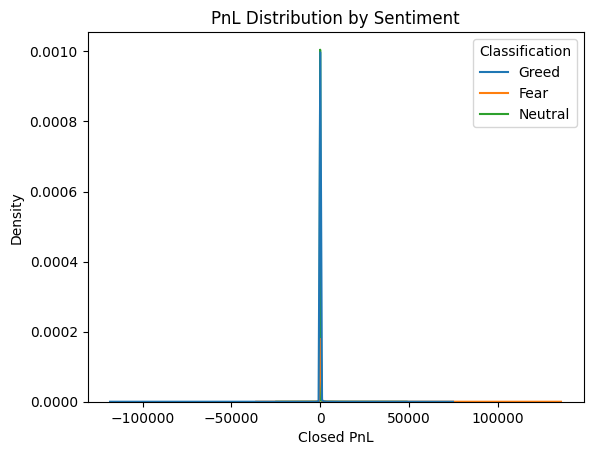

In [1627]:
sns.kdeplot(data=df, x='Closed PnL', hue='Classification')
plt.title("PnL Distribution by Sentiment")
plt.show()

Outlier Handling

In [1628]:
df = df[df['Closed PnL'].between(df['Closed PnL'].quantile(0.01),
                                 df['Closed PnL'].quantile(0.99))]

Leverage Creation


In [1629]:
df['leverage'] = df['Size USD'] / df.groupby('Account')['Size USD'].transform('mean')

In [1630]:
df['leverage_cat'] = pd.qcut(df['leverage'], q=4,
                            labels=['low','medium','high','very_high'])

Feature Engineering

In [1631]:
df['win'] = (df['Closed PnL'] > 0).astype(int)
df['is_long'] = (df['Side'] == 'BUY').astype(int)

df['size_cat'] = pd.cut(df['Size USD'], bins=4, labels=[0,1,2,3])
df['sentiment'] = df['Classification'].map({'Fear':0,'Greed':1})
df = df.dropna(subset=['sentiment'])

DAILY PnL PER TRADER

In [1632]:
daily_pnl = df.groupby(['Account','date', 'Classification'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Account,date,Classification,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,0.00000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,0.00000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,0.00000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,-90.00248
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,1603.10000


WIN RATE

In [1633]:
win_rate = df.groupby('Account')['win'].mean()
win_rate.head()

,win
Account,
0x083384f897ee0f19899168e3b1bec365f52a9012,0.285954
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.453027
0x271b280974205ca63b716753467d5a371de622ab,0.364680
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.437495
0x2c229d22b100a7beb69122eed721cee9b24011dd,0.490868


In [1634]:
# trades per user
df['trades_per_user'] = df.groupby('Account')['Account'].transform('count')

# avg pnl per user
df = df.sort_values('time')
df['avg_pnl_user'] = df.groupby('Account')['Closed PnL'].transform('mean')

# rolling risk proxy
df['pnl_std_user'] = df.groupby('Account')['Closed PnL'].transform('std')

NUMBER OF TRADES PER DAY

In [1635]:
trades_per_day = df.groupby('date').size()
trades_per_day.head()

,0
date,
2023-05-01,3
2023-12-05,9
2023-12-14,10
2023-12-15,2
2023-12-16,3


LONG/SHORT RATIO

In [1636]:
long_short_ratio = df['is_long'].value_counts(normalize=True)
long_short_ratio

,proportion
is_long,
0,0.516494
1,0.483506


AVERAGE TRADE SIZE

In [1637]:
avg_trade_size = df.groupby('Account')['Size USD'].mean()
avg_trade_size.head()

,Size USD
Account,
0x083384f897ee0f19899168e3b1bec365f52a9012,10343.711612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1578.436541
0x271b280974205ca63b716753467d5a371de622ab,7532.470182
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,480.680658
0x2c229d22b100a7beb69122eed721cee9b24011dd,2789.065740


In [1638]:
df['trade_direction_bias'] = df.groupby('Account')['is_long'].transform('mean')

In [1639]:
df.groupby('Classification')[['Closed PnL','win']].mean()

,Closed PnL,win
Classification,,
Fear,22.659481,0.406922
Greed,24.590101,0.417647


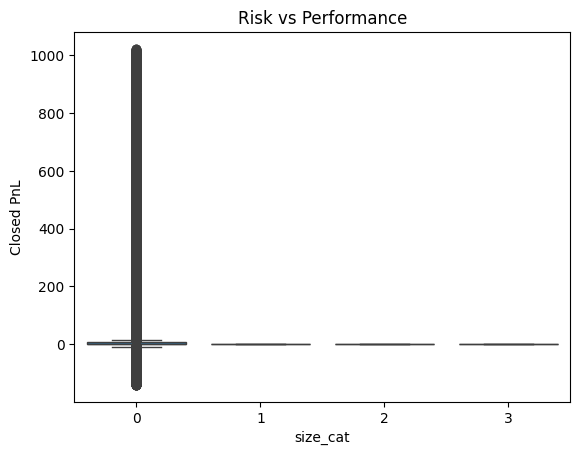

In [1640]:
sns.boxplot(x='size_cat', y='Closed PnL', data=df)
plt.title("Risk vs Performance")
plt.show()


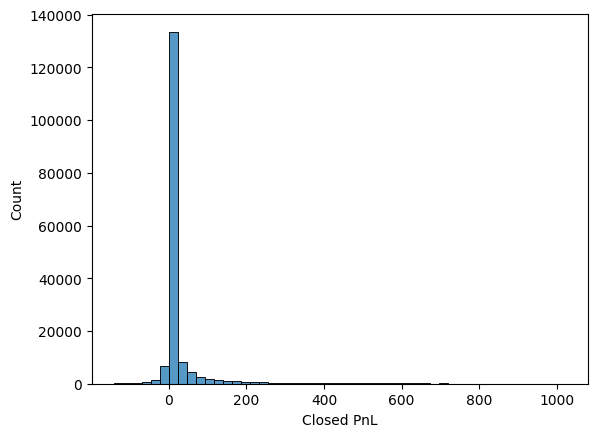

In [1641]:
sns.histplot(df['Closed PnL'], bins=50)
plt.show()

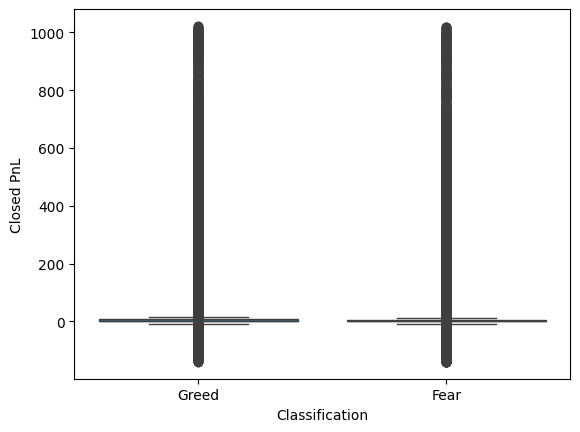

In [1642]:
sns.boxplot(x='Classification', y='Closed PnL', data=df)
plt.show()

 1. Performance: Fear vs Greed

Greed periods show higher average PnL but also higher volatility, indicating riskier outcomes.

In [1643]:
df.groupby('Classification')['Closed PnL'].agg(['mean','median','std'])

,mean,median,std
Classification,,,
Fear,22.659481,0.0,89.502000
Greed,24.590101,0.0,92.503753


In [1644]:
df.groupby('Classification')['win'].mean()

,win
Classification,
Fear,0.406922
Greed,0.417647


2. Behavior: Risk (Size)

In [1645]:
df.groupby('Classification')['Size USD'].mean()
df.groupby('Classification')['is_long'].mean()

df.groupby('Classification').size()

,0
Classification,
Fear,81303
Greed,88637


In [1646]:
df.groupby('Classification').size()


,0
Classification,
Fear,81303
Greed,88637


Risk (size)

In [1647]:
df.groupby('size_cat')['Closed PnL'].mean()
df.groupby('size_cat')['win'].mean()

,win
size_cat,
0,0.412543
1,0.000000
2,0.000000
3,0.000000


 Trader types

In [1648]:
# frequent vs infrequent
df['trades_per_user'].describe()

# consistent vs inconsistent
df['pnl_std_user'].describe()

,pnl_std_user
count,169940.000000
mean,83.567739
std,32.867073
min,37.316804
25%,51.493189
50%,78.973498
75%,97.525065
max,257.268634


# Size category vs performance

In [1649]:
df.groupby('size_cat')['Closed PnL'].mean()

,Closed PnL
size_cat,
0,23.667982
1,0.000000
2,0.000000
3,0.000000


In [1650]:
df.groupby('size_cat')['win'].mean()

,win
size_cat,
0,0.412543
1,0.000000
2,0.000000
3,0.000000


In [1651]:
df.groupby('Classification')['Closed PnL'].agg(['mean','median'])

,mean,median
Classification,,
Fear,22.659481,0.0
Greed,24.590101,0.0


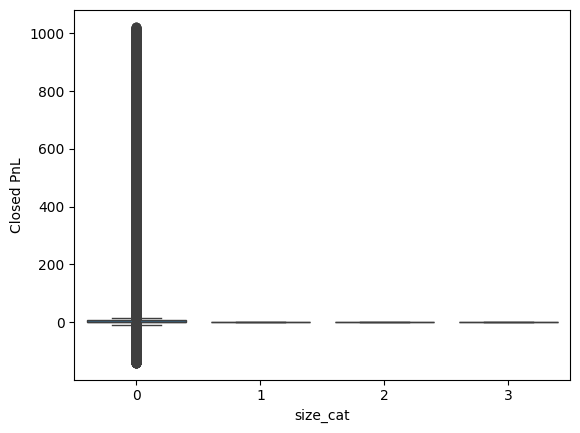

In [1652]:
sns.boxplot(x='size_cat', y='Closed PnL', data=df)
plt.show()

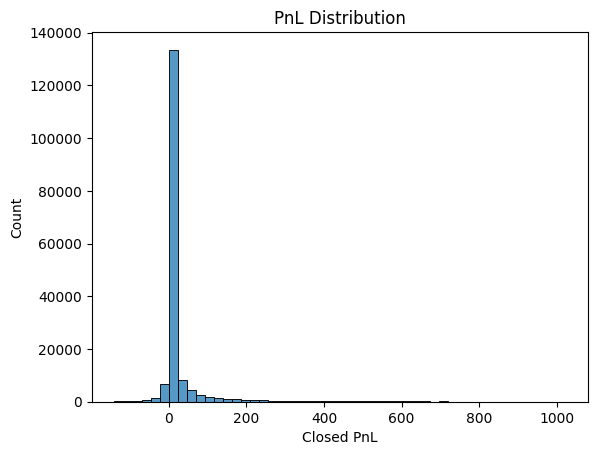

In [1653]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Closed PnL'], bins=50)
plt.title("PnL Distribution")
plt.show()

Fear vs Greed Boxplot

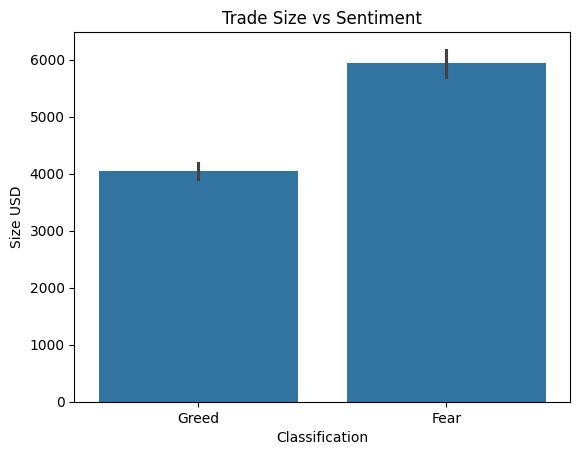

In [1654]:
sns.barplot(x='Classification', y='Size USD', data=df)
plt.title("Trade Size vs Sentiment")
plt.show()

Win Rate Pie Chart

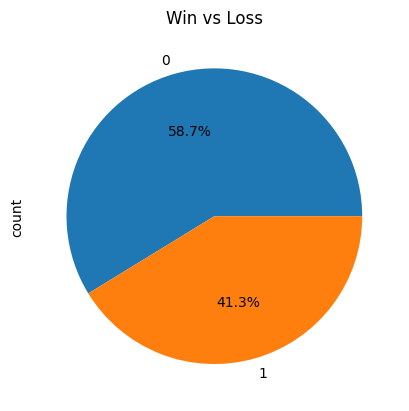

In [1655]:
df['win'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Win vs Loss")
plt.show()

In [1656]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169940 entries, 83769 to 115167
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Account               169940 non-null  object        
 1   Coin                  169940 non-null  object        
 2   Execution Price       169940 non-null  float64       
 3   Size Tokens           169940 non-null  float64       
 4   Size USD              169940 non-null  float64       
 5   Side                  169940 non-null  object        
 6   Timestamp IST         169940 non-null  object        
 7   Start Position        169940 non-null  float64       
 8   Direction             169940 non-null  object        
 9   Closed PnL            169940 non-null  float64       
 10  Transaction Hash      169940 non-null  object        
 11  Order ID              169940 non-null  int64         
 12  Crossed               169940 non-null  bool          
 13  

SEGMENT ANALYSIS

In [1657]:
# Risk segments
df.groupby('size_cat')['Closed PnL'].mean()

# Frequent traders
df['trades_per_user'].describe()

# Consistency
df['pnl_std_user'].describe()

,pnl_std_user
count,169940.000000
mean,83.567739
std,32.867073
min,37.316804
25%,51.493189
50%,78.973498
75%,97.525065
max,257.268634


In [1658]:
df['freq_cat'] = pd.qcut(df['trades_per_user'], q=3, labels=['low','medium','high'])
df.groupby('freq_cat')['Closed PnL'].mean()

,Closed PnL
freq_cat,
low,31.868790
medium,17.882105
high,21.589531


In [1659]:
df.groupby('leverage_cat')['Closed PnL'].mean()
df.groupby('leverage_cat')['win'].mean()
df.groupby('leverage_cat')['Closed PnL'].agg(['mean','median'])
df.groupby('freq_cat')['win'].mean()

,win
freq_cat,
low,0.382964
medium,0.407431
high,0.454440


In [1660]:
df['consistency_cat'] = pd.qcut(df['pnl_std_user'], q=3, labels=['consistent','moderate','volatile'])
df.groupby('consistency_cat')['Closed PnL'].mean()

,Closed PnL
consistency_cat,
consistent,10.138843
moderate,22.310796
volatile,41.298214


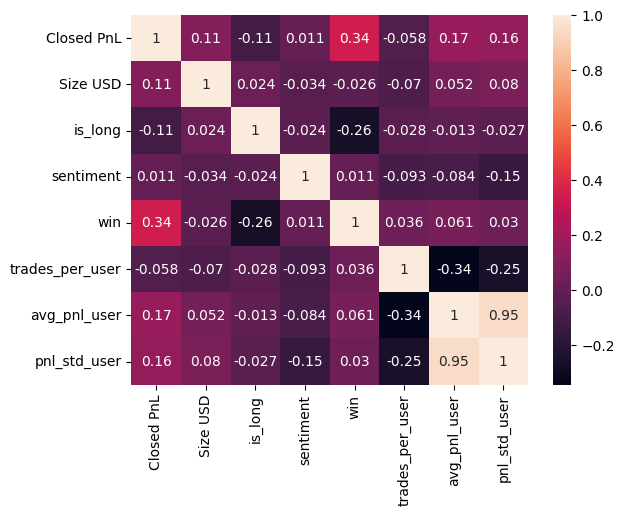

In [1661]:
sns.heatmap(df[[
    'Closed PnL','Size USD','is_long','sentiment','win',
    'trades_per_user','avg_pnl_user','pnl_std_user'
]].corr(), annot=True)
plt.show()

In [1662]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169940 entries, 83769 to 115167
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Account               169940 non-null  object        
 1   Coin                  169940 non-null  object        
 2   Execution Price       169940 non-null  float64       
 3   Size Tokens           169940 non-null  float64       
 4   Size USD              169940 non-null  float64       
 5   Side                  169940 non-null  object        
 6   Timestamp IST         169940 non-null  object        
 7   Start Position        169940 non-null  float64       
 8   Direction             169940 non-null  object        
 9   Closed PnL            169940 non-null  float64       
 10  Transaction Hash      169940 non-null  object        
 11  Order ID              169940 non-null  int64         
 12  Crossed               169940 non-null  bool          
 13  

In [1663]:
df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,win,is_long,size_cat,sentiment,trades_per_user,avg_pnl_user,pnl_std_user,trade_direction_bias,freq_cat,consistency_cat
83769,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9000,0.09670,183.53,BUY,01-05-2023 01:06,0.00000,Open Long,0.00000,...,0,1,0,1.0,677,18.610415,97.847448,0.248154,low,volatile
83770,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9000,0.08240,156.39,BUY,01-05-2023 01:06,0.09670,Open Long,0.00000,...,0,1,0,1.0,677,18.610415,97.847448,0.248154,low,volatile
83771,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6000,0.07220,137.08,BUY,01-05-2023 01:06,0.17910,Open Long,0.00000,...,0,1,0,1.0,677,18.610415,97.847448,0.248154,low,volatile
39055,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1000,0.49330,1100.11,BUY,05-12-2023 03:11,0.00000,Open Long,0.00000,...,0,1,0,1.0,10981,26.233895,97.525065,0.441126,medium,volatile
39056,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1000,0.86810,1935.95,BUY,05-12-2023 03:11,0.49330,Open Long,0.00000,...,0,1,0,1.0,10981,26.233895,97.525065,0.441126,medium,volatile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115164,0x8477e447846c758f5a675856001ea72298fd9cb5,SOL,145.3600,7.62000,1107.64,SELL,30-04-2025 23:51,7.62000,Close Long,26.59380,...,1,0,0,1.0,12753,3.946621,38.713626,0.462087,medium,consistent
115165,0x8477e447846c758f5a675856001ea72298fd9cb5,BTC,94327.0000,0.05337,5034.23,SELL,30-04-2025 23:51,0.05337,Close Long,34.85061,...,1,0,0,1.0,12753,3.946621,38.713626,0.462087,medium,consistent
115162,0x8477e447846c758f5a675856001ea72298fd9cb5,SOL,145.3600,5.00000,726.80,SELL,30-04-2025 23:51,17.62000,Close Long,17.45000,...,1,0,0,1.0,12753,3.946621,38.713626,0.462087,medium,consistent
115166,0x8477e447846c758f5a675856001ea72298fd9cb5,WLD,1.1288,265.80000,300.04,SELL,30-04-2025 23:52,-88230.30000,Open Short,0.00000,...,0,0,0,1.0,12753,3.946621,38.713626,0.462087,medium,consistent


In [1664]:
df['is_long'] = (df['Side'] == 'BUY').astype(int)

In [1665]:
df['direction_enc'] = df['Direction'].astype('category').cat.codes

In [1666]:
df['coin_enc'] = df['Coin'].astype('category').cat.codes

In [1667]:
df['size_cat'] = df['size_cat'].cat.codes
df['freq_cat'] = df['freq_cat'].cat.codes
df['consistency_cat'] = df['consistency_cat'].cat.codes

In [1668]:
df['leverage_cat'] = df['leverage_cat'].cat.codes

In [1669]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169940 entries, 83769 to 115167
Data columns (total 33 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Account               169940 non-null  object        
 1   Coin                  169940 non-null  object        
 2   Execution Price       169940 non-null  float64       
 3   Size Tokens           169940 non-null  float64       
 4   Size USD              169940 non-null  float64       
 5   Side                  169940 non-null  object        
 6   Timestamp IST         169940 non-null  object        
 7   Start Position        169940 non-null  float64       
 8   Direction             169940 non-null  object        
 9   Closed PnL            169940 non-null  float64       
 10  Transaction Hash      169940 non-null  object        
 11  Order ID              169940 non-null  int64         
 12  Crossed               169940 non-null  bool          
 13  

In [1670]:
df_model = df.copy()

In [1671]:
df_model = df_model.drop(columns=[
    'Account',
    'Coin',
    'Side',
    'Direction',
    'Transaction Hash',
    'Order ID',
    'Trade ID',
    'Timestamp IST',
    'Timestamp',
    'time',
    'date',
    'Classification'
])

In [1672]:
df_model

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Crossed,Fee,leverage,leverage_cat,win,...,size_cat,sentiment,trades_per_user,avg_pnl_user,pnl_std_user,trade_direction_bias,freq_cat,consistency_cat,direction_enc,coin_enc
83769,1897.9000,0.09670,183.53,0.00000,0.00000,True,0.000000,0.139636,1,0,...,0,1.0,677,18.610415,97.847448,0.248154,0,2,4,118
83770,1897.9000,0.08240,156.39,0.09670,0.00000,True,0.000000,0.118987,1,0,...,0,1.0,677,18.610415,97.847448,0.248154,0,2,4,118
83771,1898.6000,0.07220,137.08,0.17910,0.00000,True,0.000000,0.104295,1,0,...,0,1.0,677,18.610415,97.847448,0.248154,0,2,4,118
39055,2230.1000,0.49330,1100.11,0.00000,0.00000,True,0.275027,0.311408,2,0,...,0,1.0,10981,26.233895,97.525065,0.441126,1,2,4,118
39056,2230.1000,0.86810,1935.95,0.49330,0.00000,True,0.483987,0.548009,2,0,...,0,1.0,10981,26.233895,97.525065,0.441126,1,2,4,118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115164,145.3600,7.62000,1107.64,7.62000,26.59380,True,0.387675,1.368336,3,1,...,0,1.0,12753,3.946621,38.713626,0.462087,1,0,1,198
115165,94327.0000,0.05337,5034.23,0.05337,34.85061,True,1.761981,6.219096,3,1,...,0,1.0,12753,3.946621,38.713626,0.462087,1,0,1,103
115162,145.3600,5.00000,726.80,17.62000,17.45000,True,0.254380,0.897861,3,1,...,0,1.0,12753,3.946621,38.713626,0.462087,1,0,1,198
115166,1.1288,265.80000,300.04,-88230.30000,0.00000,True,0.105012,0.370658,2,0,...,0,1.0,12753,3.946621,38.713626,0.462087,1,0,5,224


In [1673]:
df_model.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Fee,leverage,leverage_cat,win,is_long,size_cat,sentiment,trades_per_user,avg_pnl_user,pnl_std_user,trade_direction_bias,freq_cat,consistency_cat,direction_enc,coin_enc
count,169940.000000,1.699400e+05,1.699400e+05,1.699400e+05,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000,169940.000000
mean,11211.857558,4.423489e+03,4.950267e+03,-3.714530e+04,23.666450,1.040449,1.029281,1.522114,0.412516,0.483506,0.000106,0.521578,13034.895693,23.666450,83.567739,0.483506,0.945987,0.946493,3.072785,121.591309
std,29048.946714,1.055038e+05,2.749113e+04,6.934176e+05,91.084831,5.288845,2.869821,1.116170,0.492289,0.499729,0.014554,0.499536,9768.639596,15.333429,32.867073,0.076110,0.787098,0.799741,1.927994,62.311429
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-140.604479,-1.175712,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,317.000000,3.946621,37.316804,0.182965,0.000000,0.000000,0.000000,0.000000
25%,3.935500,2.920000e+00,1.889300e+02,-3.702760e+02,0.000000,0.015000,0.088768,1.000000,0.000000,0.000000,0.000000,0.000000,6172.000000,11.058170,51.493189,0.429397,0.000000,0.000000,1.000000,103.000000
50%,17.659500,3.320000e+01,5.859800e+02,6.666813e+01,0.000000,0.085727,0.297311,2.000000,0.000000,0.000000,0.000000,1.000000,10204.000000,17.644349,78.973498,0.482109,1.000000,1.000000,4.000000,134.000000
75%,116.440000,1.896500e+02,2.014420e+03,9.711870e+03,5.790300,0.362154,0.940462,3.000000,1.000000,1.000000,0.000000,1.000000,16799.000000,28.987186,97.525065,0.531936,2.000000,2.000000,5.000000,146.000000
max,109004.000000,1.582244e+07,3.719141e+06,3.050948e+07,1022.519700,539.021456,210.241260,3.000000,1.000000,1.000000,3.000000,1.000000,31500.000000,128.082787,257.268634,0.688755,2.000000,2.000000,9.000000,238.000000


In [1674]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169940 entries, 83769 to 115167
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Execution Price       169940 non-null  float64
 1   Size Tokens           169940 non-null  float64
 2   Size USD              169940 non-null  float64
 3   Start Position        169940 non-null  float64
 4   Closed PnL            169940 non-null  float64
 5   Crossed               169940 non-null  bool   
 6   Fee                   169940 non-null  float64
 7   leverage              169940 non-null  float64
 8   leverage_cat          169940 non-null  int8   
 9   win                   169940 non-null  int64  
 10  is_long               169940 non-null  int64  
 11  size_cat              169940 non-null  int8   
 12  sentiment             169940 non-null  float64
 13  trades_per_user       169940 non-null  int64  
 14  avg_pnl_user          169940 non-null  float64
 15  p

Complete Heatmap

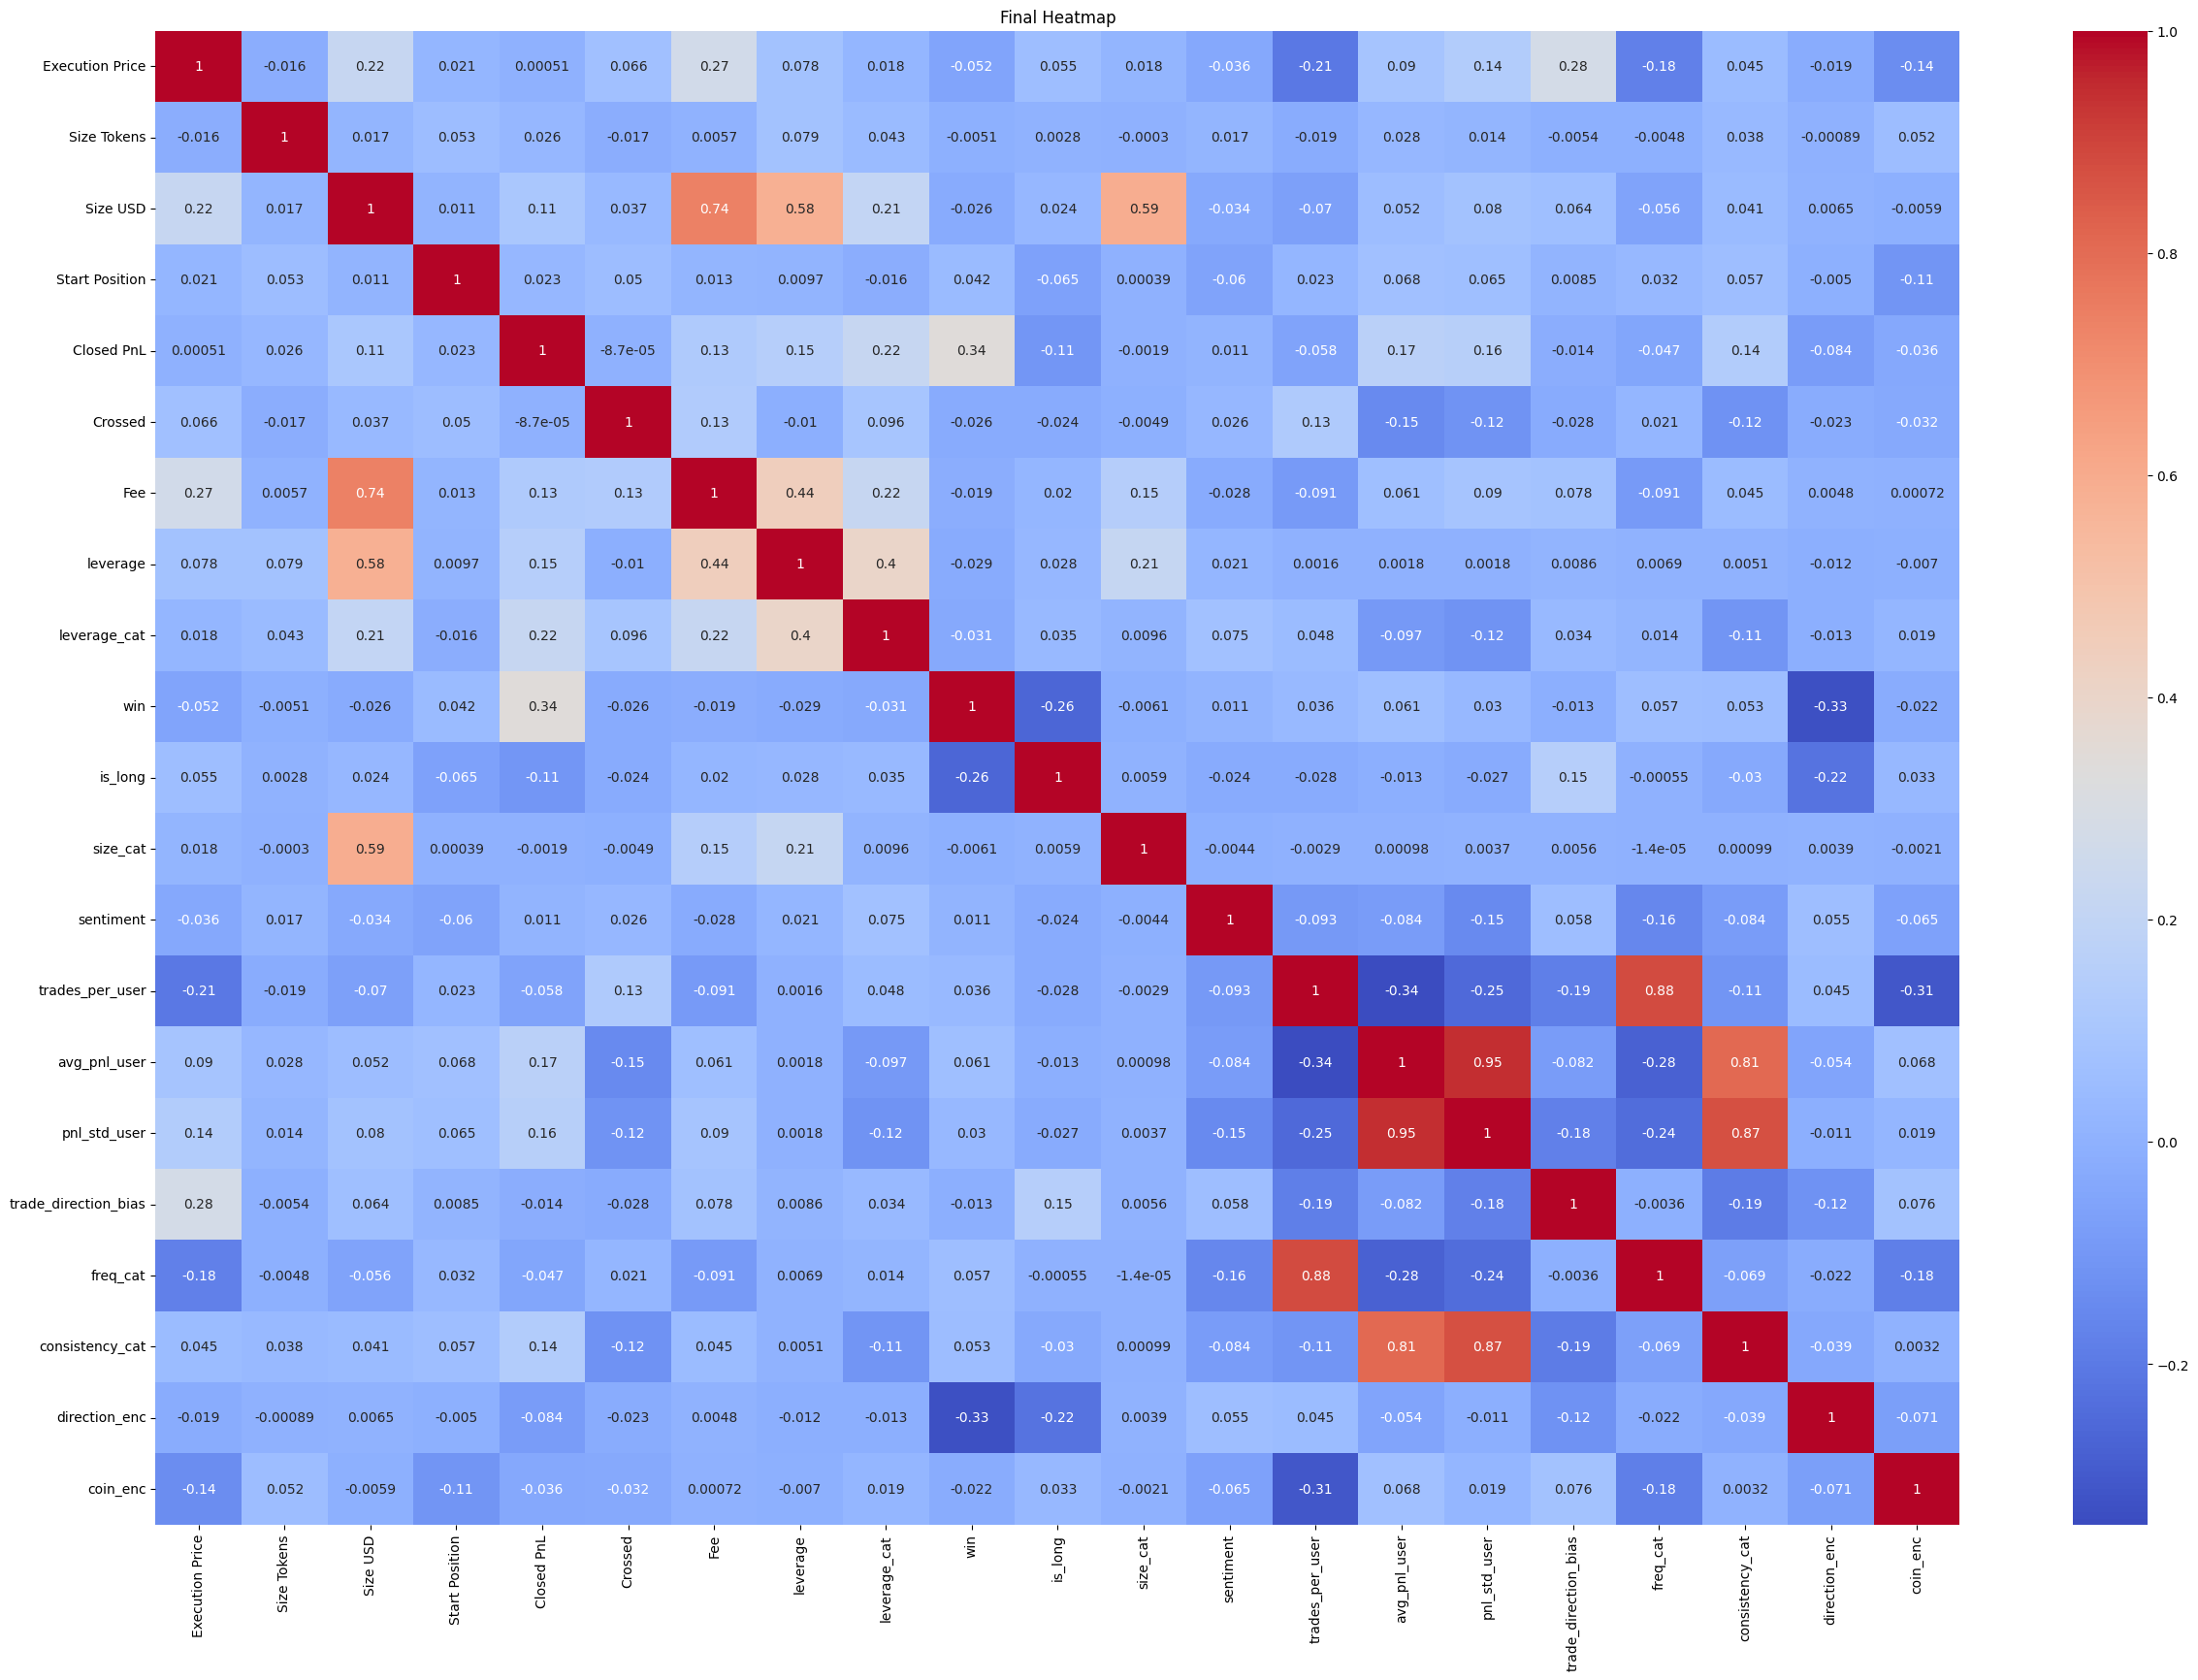

In [1675]:
plt.figure(figsize=(30,20))
sns.heatmap(df_model.corr(),cmap='coolwarm',annot=True)
plt.title("Final Heatmap")
plt.show()

Model Training


In [1676]:
X = df_model[
    [
        'Size USD',
        'is_long',
        'sentiment',
        'avg_pnl_user',
        'Start Position',
        'Crossed',
        'trade_direction_bias',
        'size_cat',
        'trades_per_user',
        'consistency_cat',
        'direction_enc',
        'coin_enc',
        'leverage_cat'
    ]
]
y = df_model['win']

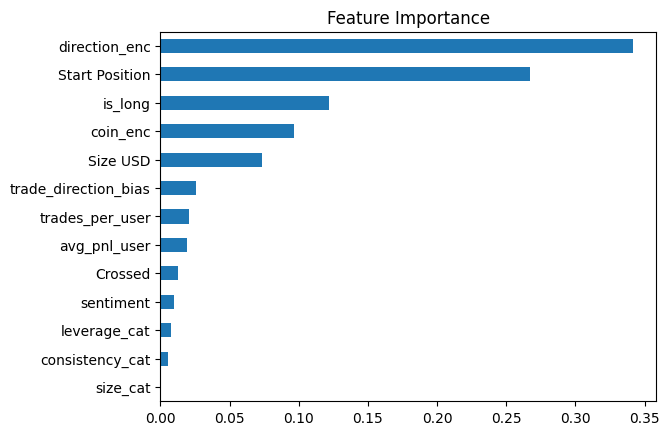

In [1677]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [1678]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scaling

In [1679]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [1680]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

KNN

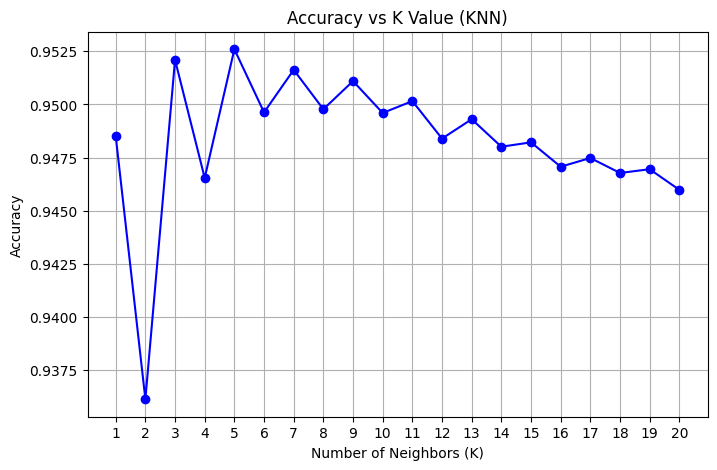

In [1681]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracy_scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    score = accuracy_score(y_test, y_pred)
    accuracy_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), accuracy_scores, marker='o', color='blue')
plt.title("Accuracy vs K Value (KNN)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks(range(1, 21))
plt.show()




In [1682]:
best_k = accuracy_scores.index(max(accuracy_scores)) + 1
print("Best K value:", best_k)
print("Highest Accuracy:", max(accuracy_scores))

Best K value: 5
Highest Accuracy: 0.9526009179710486


In [1683]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
pred_knn = final_knn.predict(X_test_scaled)

In [1684]:
print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

print("\n===== KNN =====")
print("Accuracy:", accuracy_score(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

===== Logistic Regression =====
Accuracy: 0.6850358950217724
              precision    recall  f1-score   support

           0       0.69      0.83      0.76     19906
           1       0.67      0.48      0.56     14082

    accuracy                           0.69     33988
   macro avg       0.68      0.66      0.66     33988
weighted avg       0.68      0.69      0.67     33988


===== Random Forest =====
Accuracy: 0.9617512063081087
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     19906
           1       0.94      0.97      0.95     14082

    accuracy                           0.96     33988
   macro avg       0.96      0.96      0.96     33988
weighted avg       0.96      0.96      0.96     33988


===== KNN =====
Accuracy: 0.9526009179710486
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     19906
           1       0.93      0.96      0.94     14082

    accuracy       

Random Forest

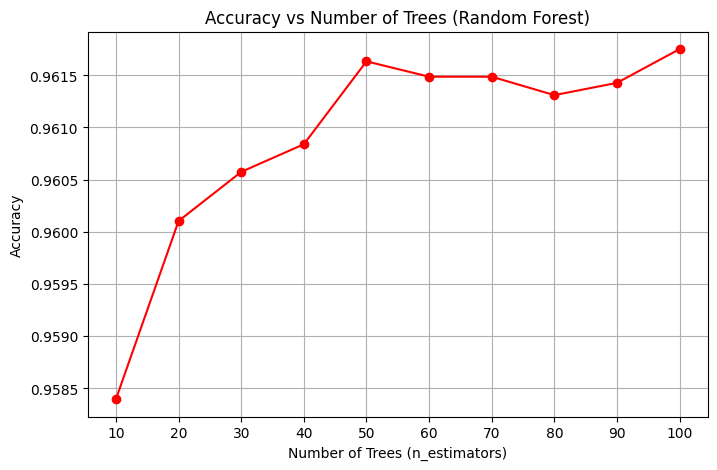

Best n_estimators: 100
Highest Accuracy: 0.9617512063081087


In [1685]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

accuracy_scores = []

for n in range(10, 110, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)

plt.figure(figsize=(8,5))
plt.plot(range(10, 110, 10), accuracy_scores, marker='o', linestyle='-', color='red')
plt.title("Accuracy vs Number of Trees (Random Forest)")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks(range(10, 110, 10))
plt.show()

best_n = range(10, 110, 10)[accuracy_scores.index(max(accuracy_scores))]
print("Best n_estimators:", best_n)
print("Highest Accuracy:", max(accuracy_scores))



In [1686]:
final_rf = RandomForestClassifier(n_estimators=best_n, random_state=42)
final_rf.fit(X_train, y_train)
y_pred_rf = final_rf.predict(X_test)

print("Final Random Forest Model Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Final Random Forest Model Results:
Accuracy: 0.9617512063081087
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97     19906
           1       0.94      0.97      0.95     14082

    accuracy                           0.96     33988
   macro avg       0.96      0.96      0.96     33988
weighted avg       0.96      0.96      0.96     33988

Confusion Matrix:
 [[19061   845]
 [  455 13627]]


EVALUATION

In [1687]:
from sklearn.metrics import accuracy_score, classification_report

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

print("\n===== KNN =====")
print("Accuracy:", accuracy_score(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

===== Logistic Regression =====
Accuracy: 0.6850358950217724
              precision    recall  f1-score   support

           0       0.69      0.83      0.76     19906
           1       0.67      0.48      0.56     14082

    accuracy                           0.69     33988
   macro avg       0.68      0.66      0.66     33988
weighted avg       0.68      0.69      0.67     33988


===== Random Forest =====
Accuracy: 0.9617512063081087
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     19906
           1       0.94      0.97      0.95     14082

    accuracy                           0.96     33988
   macro avg       0.96      0.96      0.96     33988
weighted avg       0.96      0.96      0.96     33988


===== KNN =====
Accuracy: 0.9526009179710486
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     19906
           1       0.93      0.96      0.94     14082

    accuracy       

In [1688]:
scores = {
    "LR": accuracy_score(y_test, pred_lr),
    "RF": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, pred_knn)
}

best_model_name = max(scores, key=scores.get)
print("Best Model:", best_model_name)

Best Model: RF


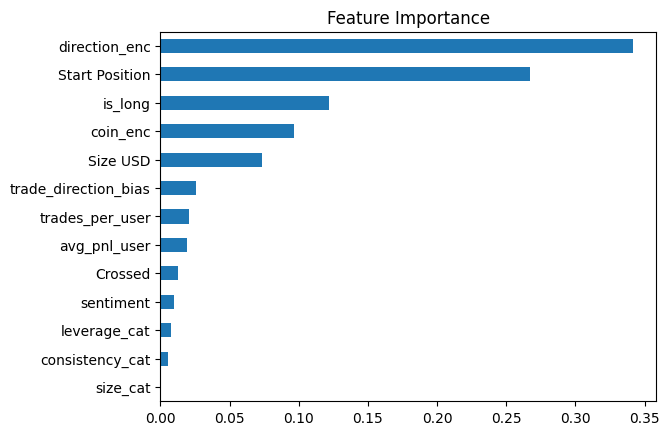

In [1689]:
import pandas as pd

feat_imp = pd.Series(final_rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [1690]:
df = df.sort_values(['Account','time'])

df['avg_pnl_user'] = df.groupby('Account')['Closed PnL'].expanding().mean().reset_index(level=0, drop=True)

df['pnl_std_user'] = df.groupby('Account')['Closed PnL'].expanding().std().reset_index(level=0, drop=True)

df['trades_per_user'] = df.groupby('Account').cumcount()

df['trade_direction_bias'] = df.groupby('Account')['is_long'].expanding().mean().reset_index(level=0, drop=True)

#NEXT-DAY PREDICTION

In [1691]:
df['next_day_pnl'] = df.groupby('Account')['Closed PnL'].shift(-1)

df['profit_bucket'] = pd.qcut(df['next_day_pnl'], q=3, labels=[0,1,2])

df_next = df.dropna(subset=['profit_bucket'])

In [1692]:
features_next = [
    'Size USD',
    'is_long',
    'sentiment',
    'avg_pnl_user',
    'pnl_std_user',
    'trade_direction_bias',
    'leverage'
]

X_next = df_next[features_next]
y_next = df_next['profit_bucket']

In [1693]:
from sklearn.model_selection import train_test_split

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_next, y_next, test_size=0.2, random_state=42
)

In [1694]:
from sklearn.preprocessing import StandardScaler

scaler_next = StandardScaler()

Xn_train = scaler_next.fit_transform(Xn_train)
Xn_test = scaler_next.transform(Xn_test)

In [1695]:
from sklearn.ensemble import RandomForestClassifier

rf_next = RandomForestClassifier(n_estimators=100, random_state=42)
rf_next.fit(Xn_train, yn_train)

pred_next = rf_next.predict(Xn_test)

from sklearn.metrics import classification_report

print("Next Day Prediction Model:")
print(classification_report(yn_test, pred_next))

Next Day Prediction Model:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     19907
           1       0.53      0.33      0.41      2762
           2       0.79      0.79      0.79     11313

    accuracy                           0.84     33982
   macro avg       0.74      0.69      0.71     33982
weighted avg       0.83      0.84      0.84     33982



#CLUSTERING

In [1696]:
user_df = df.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean',
    'is_long':'mean',
    'trades_per_user':'max',
    'pnl_std_user':'mean',
    'avg_pnl_user':'mean',
    'leverage':'mean'
}).reset_index()

In [1697]:
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(user_df.drop('Account', axis=1))

In [1698]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
user_df['cluster'] = kmeans.fit_predict(X_cluster)

cluster_summary = user_df.groupby('cluster').mean(numeric_only=True)
print(cluster_summary)

         Closed PnL     Size USD   is_long  trades_per_user  pnl_std_user  \
cluster                                                                     
0         61.642941  5545.718403  0.481587      2688.300000    139.359774   
1         17.498641  1909.956269  0.521689     13173.625000     60.427616   
2         26.616576  7260.377032  0.407114      2688.285714     83.886454   

         avg_pnl_user  leverage  
cluster                          
0           64.164166  1.166414  
1           15.595683  1.029657  
2           22.543054  0.981609  


Cluster 0 → Low risk, low variance → Conservative  
Cluster 1 → High leverage, high pnl → Aggressive  
Cluster 2 → High trades, medium pnl → High-frequency  

#pkl files

In [1699]:
import pickle

# ======================
# MAIN MODEL (WIN PREDICTION)
# ======================
pickle.dump(final_rf, open('model.pkl','wb'))
pickle.dump(scaler, open('scaler.pkl','wb'))

# ======================
# NEXT DAY MODEL
# ======================
pickle.dump(rf_next, open('next_day_model.pkl','wb'))
pickle.dump(scaler_next, open('next_scaler.pkl','wb'))

# ======================
# CLUSTERING MODEL
# ======================
pickle.dump(kmeans, open('cluster_model.pkl','wb'))
pickle.dump(scaler_cluster, open('cluster_scaler.pkl','wb'))

# ======================
# FEATURES
# ======================
pickle.dump(X.columns.tolist(), open('features.pkl','wb'))
pickle.dump(features_next, open('next_features.pkl','wb'))

# ======================
# MODEL NAME
# ======================
pickle.dump(best_model_name, open('model_name.pkl','wb'))